# 07 — Final model selection

No GridSearchCV. Inputs: `reports/tuned_model_comparison.csv`, `reports/best_params.json`, Phase 5 calibration notes, and a **new** threshold sweep on `models/tuned_xgboost.pkl`.

Artifacts for Phase 8: `models/final_model.pkl` **plus** existing `models/preprocessor.pkl`, and `models/final_model_config.json` (threshold).

Script: `ml/select_model.py`. **No Flask / no frontend.**

In [2]:
import json
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
if not (ROOT / "ml" / "select_model.py").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from ml.config import REPORTS_DIR
from ml.select_model import load_tuned_comparison

COMPARISON_PATH = REPORTS_DIR / "tuned_model_comparison.csv"
COLS = ["model", "roc_auc", "train_roc_auc", "roc_auc_gap", "overfit_flag"]

print(
    "Historical / model-selection comparison (Phase 6–7 hold-out). "
    "Not the FeatureBuilder production pipeline."
)
try:
    comparison = load_tuned_comparison()
except FileNotFoundError:
    print(f"Missing comparison artifact: {COMPARISON_PATH}. Display skipped; production artifacts were not changed.")
else:
    missing = [c for c in COLS if c not in comparison.columns]
    if missing:
        print(f"{COMPARISON_PATH} is missing columns: {missing}. Metrics were not recalculated.")
    else:
        display(comparison[COLS].round(4))

Historical / model-selection comparison (Phase 6–7 hold-out). Not the FeatureBuilder production pipeline.


,model,roc_auc,train_roc_auc,roc_auc_gap,overfit_flag
0,XGBoost,0.5963,0.6093,0.0130,False
1,Random Forest,0.5938,0.6643,0.0706,True
2,Logistic Regression,0.5898,0.5891,-0.0007,False
3,Decision Tree,0.5770,0.6012,0.0242,False


## 1. Tuned XGBoost threshold sweep (same grid as Phase 5 RF)

Phase 5 RF at 0.4: precision ~0.495, recall ~0.896, flagged ~86%.

Historical tuned XGBoost threshold table (saved; not recalculated)


,threshold,precision,recall,f1,predicted_positive_rate
0,0.3,0.4774,0.9926,0.6447,0.9868
1,0.4,0.5020,0.8580,0.6334,0.8112
2,0.5,0.5610,0.4442,0.4958,0.3758
3,0.6,0.6398,0.0966,0.1678,0.0716
4,0.7,0.7184,0.0078,0.0154,0.0052


Phase 5 RF (untuned-at-the-time, for comparison)


,threshold,precision,recall,f1,predicted_positive_rate
0,0.3,0.4758,0.9980,0.6444,0.9954
1,0.4,0.4951,0.8964,0.6378,0.8594
2,0.5,0.5653,0.4127,0.4771,0.3465
3,0.6,0.6482,0.0629,0.1147,0.0460
4,0.7,0.7843,0.0021,0.0042,0.0013


Historical operating point from saved sweep: threshold 0.4 (see table above). Production threshold lives in models/final_model_config.json.


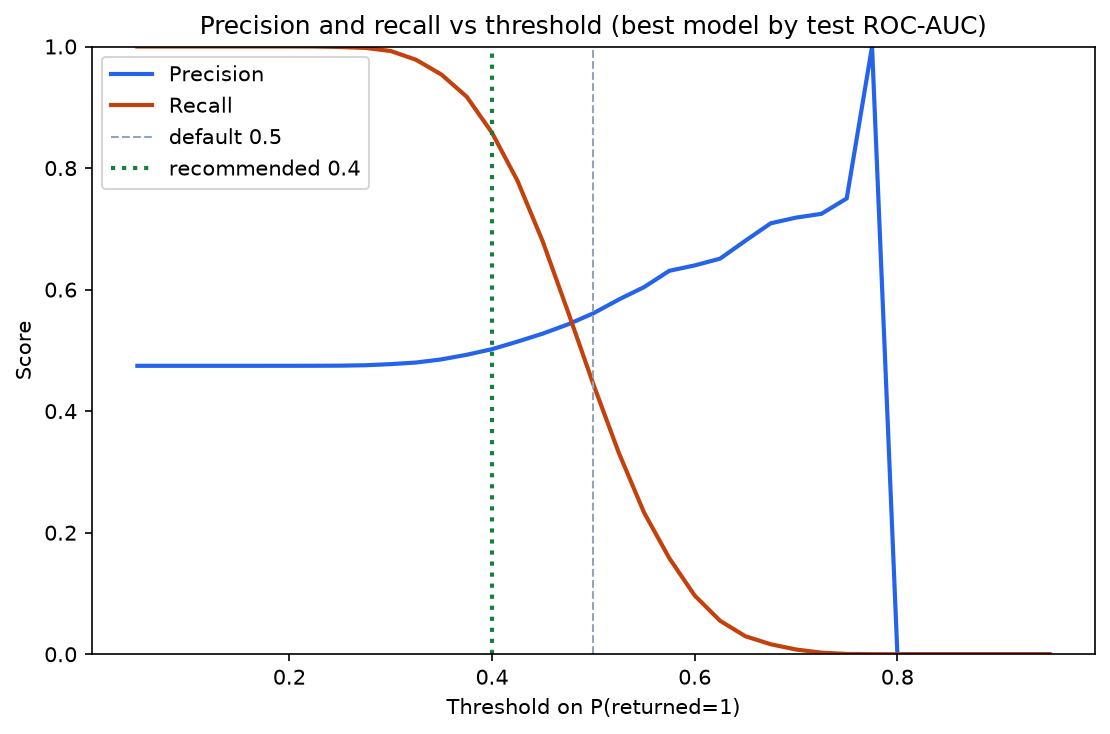

In [4]:
xgb_thr = ROOT / "reports" / "tuned_xgboost_threshold_analysis.csv"
if xgb_thr.exists():
    print("Historical tuned XGBoost threshold table (saved; not recalculated)")
    display(pd.read_csv(xgb_thr).round(4))
else:
    print(f"Missing threshold artifact: {xgb_thr}. Display skipped; production artifacts were not changed.")

rf_thr = ROOT / "reports" / "threshold_analysis.csv"
if rf_thr.exists():
    print("Phase 5 RF (untuned-at-the-time, for comparison)")
    display(pd.read_csv(rf_thr).round(4))
print(
    "Historical operating point from saved sweep: threshold 0.4 "
    "(see table above). Production threshold lives in models/final_model_config.json."
)
fig = ROOT / "reports" / "figures" / "16_tuned_xgboost_threshold.png"
if fig.exists():
    display(Image(filename=str(fig)))
else:
    print(f"Missing figure: {fig}")

## 2. Decision (four factors, not AUC alone)

**Selected model: tuned XGBoost** (`n_estimators=100`, `max_depth=3`, `learning_rate=0.2`).  
**Selected threshold: 0.4** (label `returned` if `P >= 0.4`).

1. **Highest test ROC-AUC.** XGBoost 0.596 vs RF 0.594 vs LR 0.590 vs DT 0.577. The spread among the top three is ~0.006. Phases 3–5 already showed a **~0.59 plateau**; treating 0.596 as a “much better detector” would be dishonest. AUC is a *tie-break*, not the decision.

2. **Smallest train–test gap (robustness).** LR is best (~0). Tuned XGBoost is next (**0.013**, under the 0.05 flag). RF still **0.071** even after CV. DT’s gap is closed (0.024) but it remains the weakest ranker. RF is dropped because leftover overfit is a production risk; LR stays a strong alternative.

3. **Calibration.** Phase 5: LR hugs the diagonal; untuned XGB/RF were compressed but not wild; DT was overconfident. We still treat **LR as the probability-quality reference**. Tuned XGB is a shallow booster, so scores are used with an explicit threshold rather than as well-spaced percentages. That is acceptable for **flag / don’t flag**, which is the product.

4. **Recall-first at a defensible flag rate.** Missing a true return is worse than a false alarm (intervene before fulfillment). For tuned XGB:
   - **0.3** → recall 0.99 but flags **99%** of orders — not an intervention list.
   - **0.4** → precision **0.50**, recall **0.86**, flags **81%** — same recall-first idea as Phase 5 RF, slightly more selective than RF’s 86% flagged / 90% recall.
   - **0.5** → recall **0.44** — misses most true returns; rejected despite tidier precision.

XGBoost at **0.4** is the compromise: ranking not worse than LR, **overfit closed unlike RF**, and a recall-oriented cut that is not “flag everyone.” LR would be preferred if the product needed well-calibrated percentages more than a ranked flag. DT is out.

Hold-out at 0.4: **precision 50.2%, recall 85.8%, ~81% of orders flagged.**

## 3. Saved artifacts and preprocessor smoke test

In [5]:
cfg_path = ROOT / "models" / "final_model_config.json"
if cfg_path.exists():
    cfg = json.loads(cfg_path.read_text(encoding="utf-8"))
    print("Current production config (read-only; not written by this notebook):")
    print(json.dumps(cfg, indent=2))
else:
    print(f"Missing config artifact: {cfg_path}")

summary_path = ROOT / "reports" / "final_model_summary.md"
if summary_path.exists():
    print("\nModel summary (documentation only):")
    display(Markdown(summary_path.read_text(encoding="utf-8")))
else:
    print(f"Missing summary artifact: {summary_path}")

Current production config (read-only; not written by this notebook):
{
  "model": "XGBoost",
  "includes_feature_engineering": true,
  "n_model_features": 56,
  "preprocessor": "preprocessor.pkl",
  "final_model": "final_model.pkl",
  "inference_pipeline": "inference_pipeline.pkl",
  "pairing": "Preferred: load inference_pipeline.pkl and call predict_proba on the raw 14-field DataFrame. Equivalent: preprocessor.pkl then final_model.pkl. Do not refit. Do not send engineered fields from the client.",
  "pipeline_steps": [
    "clean",
    "engineer",
    "encode_scale",
    "model"
  ],
  "raw_input_fields": [
    "customer_age",
    "product_price",
    "discount_percent",
    "product_rating",
    "past_purchase_count",
    "past_return_rate",
    "delivery_delay_days",
    "session_length_minutes",
    "num_product_views",
    "device_type",
    "product_category",
    "shipping_method",
    "payment_method",
    "used_coupon"
  ],
  "engineered_features": [
    "discount_amount",
   

The production estimator is **XGBoost** (`n_estimators=100`, `max_depth=3`, `learning_rate=0.2`) inside `models/inference_pipeline.pkl`: FeatureCleaner → FeatureBuilder → encode/scale → model. The React form still sends only the original 14 predictors; the six engineered fields are created in the pickle (train-only price tertiles `q33=12.13`, `q66=40.34`). Encoded width is **56** features. Test ROC-AUC is **0.596** (train 0.610, gap 0.014) — the same ~0.59 plateau as before feature engineering; do not advertise a large lift. Operating threshold remains **0.4** (not 0.5): hold-out precision 50.1%, recall 86.0%, flagging about 81% of orders. Pairing: load `inference_pipeline.pkl` (or `preprocessor.pkl` then `final_model.pkl`); do not refit.


Phase 8 should load **`preprocessor.pkl` then `final_model.pkl`**, apply `threshold` from `final_model_config.json`, and must not refit either object.